<a href="https://colab.research.google.com/github/cdhakami-p/CSCI-B455/blob/main/hw2/q2/hw2_q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2 Question 2**

In [1]:
# LLMs were used in certain labeled sections of the code, as well as to bug fix and clean up code overall
# Used textbook for code references
# Import initial libraries and dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder

# Load multiple EPL seasons and combine
urls = [
    'https://www.football-data.co.uk/mmz4281/2223/E0.csv',
    'https://www.football-data.co.uk/mmz4281/2122/E0.csv',
    'https://www.football-data.co.uk/mmz4281/2021/E0.csv',
]

df = pd.concat([pd.read_csv(url) for url in urls], ignore_index=True)

# Only keep needed columns
cols = ['HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'FTR']
df = df[cols].dropna()

# Rename columns
df.columns = ['Home_Shots', 'Away_Shots', 'Home_SoT', 'Away_SoT',
              'Home_Corners', 'Away_Corners', 'Home_Fouls', 'Away_Fouls',
              'Home_Yellow', 'Away_Yellow', 'Home_Red', 'Away_Red', 'Result']

# Encode result: Away win = 0, Draw = 1, Home win = 2
encoding = LabelEncoder()
df['Result'] = encoding.fit_transform(df['Result'])

features = ['Home_Shots', 'Away_Shots', 'Home_SoT', 'Away_SoT',
            'Home_Corners', 'Away_Corners', 'Home_Fouls', 'Away_Fouls',
            'Home_Yellow', 'Away_Yellow', 'Home_Red', 'Away_Red']

X = df[features]
y = df['Result']

print("Dataset shape: ", df.shape)
print("\nResult distribution: ")
print(y.value_counts().rename({0: 'Away Win', 1: 'Draw', 2: 'Home Win'}))

Dataset shape:  (1140, 13)

Result distribution: 
Result
Home Win    491
Away Win    391
Draw        258
Name: count, dtype: int64


# **PART 1:**




In [2]:
# Statistical Summary

display(X.describe().T)


,count,mean,std,min,25%,50%,75%,max
Home_Shots,1140.0,13.538596,5.604565,1.0,9.0,13.0,17.0,33.0
Away_Shots,1140.0,11.470175,5.060129,1.0,8.0,11.0,15.0,31.0
Home_SoT,1140.0,4.710526,2.565810,0.0,3.0,4.5,6.0,15.0
Away_SoT,1140.0,4.040351,2.365642,0.0,2.0,4.0,5.0,14.0
Home_Corners,1140.0,5.599123,3.045139,0.0,3.0,5.0,7.0,17.0
Away_Corners,1140.0,4.641228,2.742099,0.0,3.0,4.0,6.0,19.0
Home_Fouls,1140.0,10.625439,3.421394,1.0,8.0,10.0,13.0,23.0
Away_Fouls,1140.0,10.546491,3.565090,1.0,8.0,10.0,13.0,25.0
Home_Yellow,1140.0,1.582456,1.211320,0.0,1.0,1.0,2.0,6.0
Away_Yellow,1140.0,1.702632,1.266226,0.0,1.0,2.0,3.0,7.0


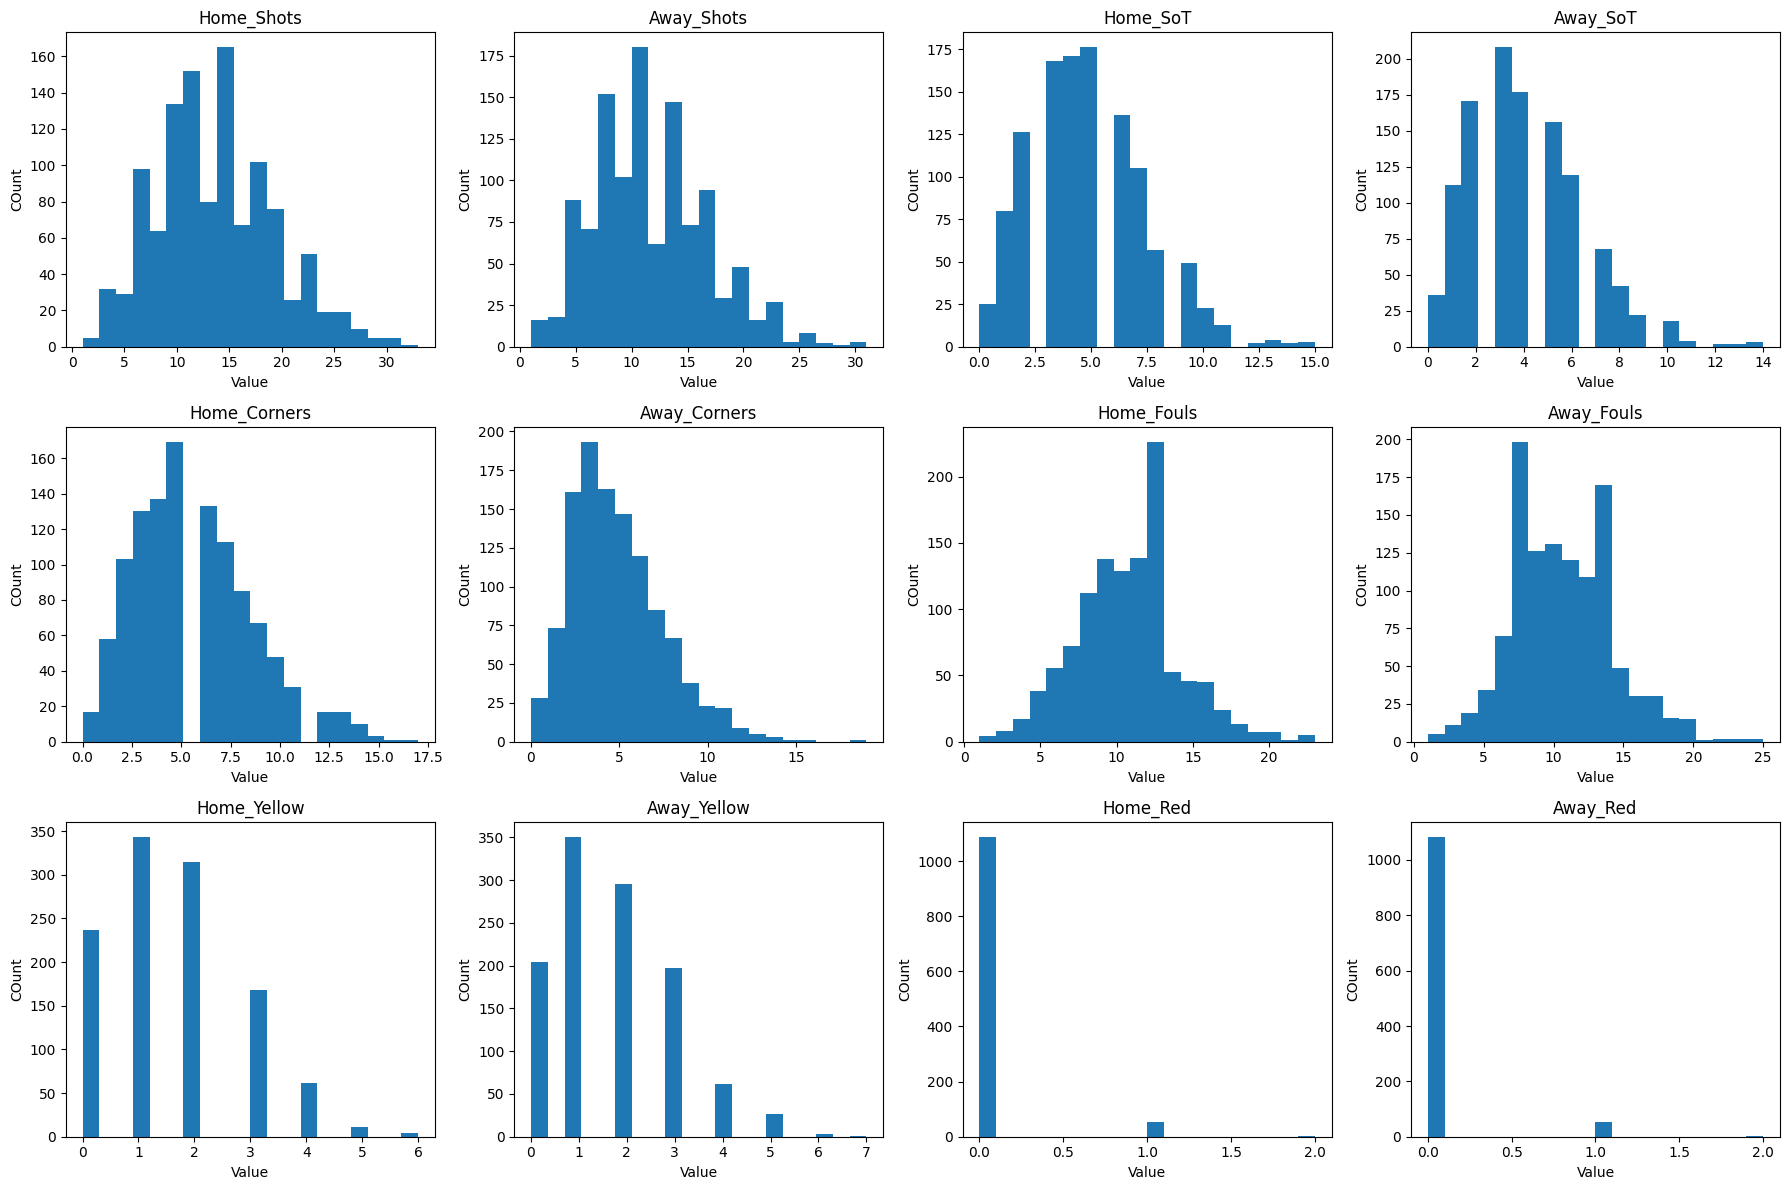

In [3]:
# Histograms

plt.figure(figsize=(18,12))

for i, col in enumerate(features, 1):
    plt.subplot(3,4,i)
    plt.hist(X[col].dropna(), bins=20)
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("COunt")

plt.tight_layout()
plt.show()

In [4]:
# Check for skew

display(X.skew())

,0
Home_Shots,0.438956
Away_Shots,0.555647
Home_SoT,0.619782
Away_SoT,0.760560
Home_Corners,0.597289
Away_Corners,0.879650
Home_Fouls,0.352567
Away_Fouls,0.391444
Home_Yellow,0.571264
Away_Yellow,0.613492


**Part 1 Summary:**

Home_Shots
 - Mean = 13.54, STD = 5.60
 - Mild right skew (0.44), roughly bell shaped distribution

Away_Shots
 - Mean = 11.47, STD = 5.06
 - Mild right skew (0.56), similar distribution to Home_Shots but slightly lower mean suggesting home teams shoot more

Home_SoT (Shots on Target)
 - Mean = 4.71, STD = 2.57
 - Moderate right skew (0.62), peaks around 4-5 shots on target

Away_SoT
 - Mean = 4.04, STD = 2.37
 - Moderate right skew (0.76), lower than home SoT consistent with home advantage for shots

Home_Corners
 - Mean = 5.60, STD = 3.05
 - Moderate right skew (0.60),

Away_Corners
 - Mean = 4.64, STD = 2.74
 - Higher right skew (0.88), home teams tend to earn more corners

Home_Fouls
 - Mean = 10.63, STD = 3.42
 - Low skew (0.35)

Away_Fouls
 - Mean = 10.55, STD = 3.57
 - Low skew (0.39), very similar to Home_Fouls

Home_Yellow
 - Mean = 1.58, STD = 1.21
 - Moderate right skew (0.57)

Away_Yellow
 - Mean = 1.70, STD = 1.27
 - Moderate right skew (0.61)

Home_Red
 - Mean = 0.049, STD = 0.22
 - Extreme right skew (4.64)

Away_Red
 - Mean = 0.054, STD = 0.24
 - Extreme right skew (4.56), same as Home_Red, extremely rare

All features are on different scales so standardization should be done before
applying SVM and logistic regression. Home_Red and Away_Red are unique features due to extreme skew and cluster around 0 since red cards are very rare.

Home advantage is visible across most features, with home teams generally having higher shots, shots on target, and corners than away teams.

# **PART 2:**



In [5]:
# Create correlation matrix

corr_matrix = df[features + ["Result"]].corr()

display(corr_matrix)

,Home_Shots,Away_Shots,Home_SoT,Away_SoT,Home_Corners,Away_Corners,Home_Fouls,Away_Fouls,Home_Yellow,Away_Yellow,Home_Red,Away_Red,Result
Home_Shots,1.000000,-0.430492,0.683416,-0.285656,0.558525,-0.356407,-0.084155,-0.054510,-0.150354,0.077889,-0.112609,0.080888,0.275545
Away_Shots,-0.430492,1.000000,-0.289751,0.682788,-0.358798,0.535894,0.002879,-0.062583,0.111554,-0.109156,0.190901,-0.122989,-0.303582
Home_SoT,0.683416,-0.289751,1.000000,-0.217355,0.325611,-0.220797,-0.053867,-0.026938,-0.163781,0.042391,-0.094307,0.070384,0.437280
Away_SoT,-0.285656,0.682788,-0.217355,1.000000,-0.238459,0.319619,-0.014511,-0.032286,0.049698,-0.086559,0.163455,-0.113685,-0.432779
Home_Corners,0.558525,-0.358798,0.325611,-0.238459,1.000000,-0.332567,-0.050492,-0.070298,-0.068744,0.067422,-0.135740,0.055400,0.093545
Away_Corners,-0.356407,0.535894,-0.220797,0.319619,-0.332567,1.000000,-0.023694,-0.090212,0.039443,-0.089418,0.091531,-0.075952,-0.062209
Home_Fouls,-0.084155,0.002879,-0.053867,-0.014511,-0.050492,-0.023694,1.000000,0.148229,0.373630,0.102549,0.058346,0.006344,-0.015985
Away_Fouls,-0.054510,-0.062583,-0.026938,-0.032286,-0.070298,-0.090212,0.148229,1.000000,0.094563,0.338656,0.005928,0.048580,0.021193
Home_Yellow,-0.150354,0.111554,-0.163781,0.049698,-0.068744,0.039443,0.373630,0.094563,1.000000,0.160534,0.001236,0.032080,-0.097881
Away_Yellow,0.077889,-0.109156,0.042391,-0.086559,0.067422,-0.089418,0.102549,0.338656,0.160534,1.000000,0.011297,-0.005453,0.038594


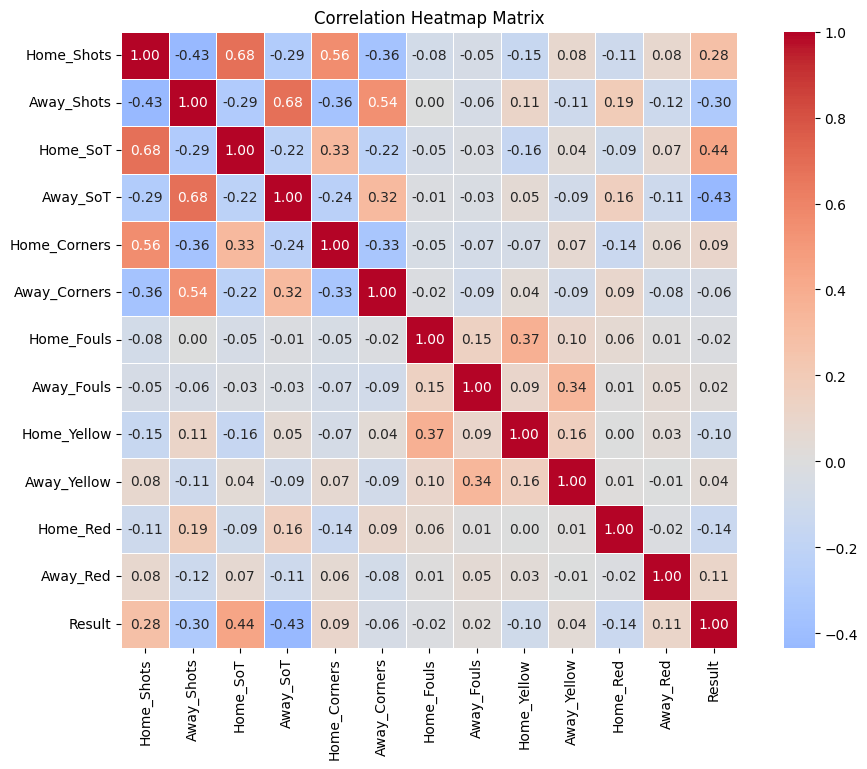

In [6]:
# Heatmap matrix

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Correlation Heatmap Matrix")
plt.show()

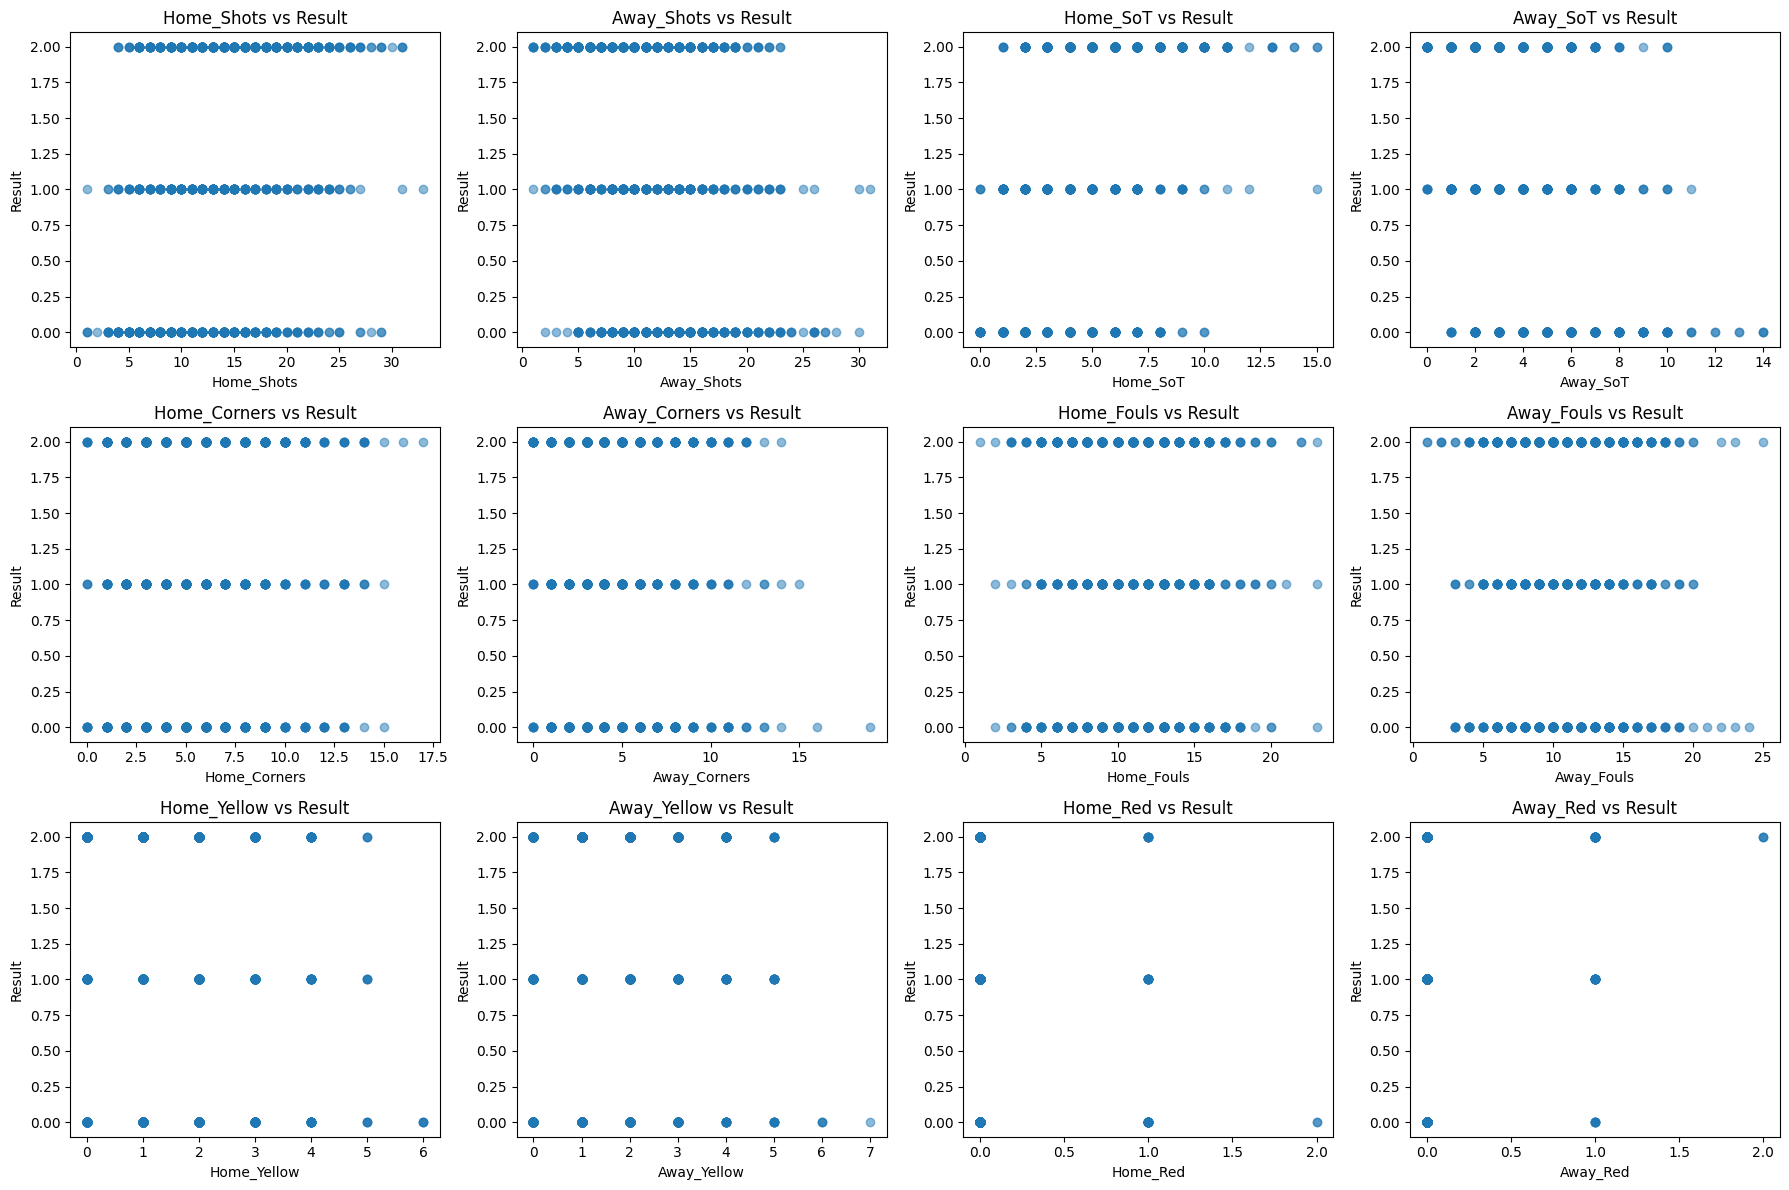

In [7]:
# Scatter plots

plt.figure(figsize=(18, 12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 4, i)
    plt.scatter(df[col], df['Result'], alpha=0.5)
    plt.title(f'{col} vs Result')
    plt.xlabel(col)
    plt.ylabel('Result')

plt.tight_layout()
plt.show()

**Part 2 Summary:**

Correlations with Result:
 - Home_SoT (0.44): Strongest positive correlation with result, meaning more home shots on target  associates with a home win
 - Away_SoT (-0.43): Strongest negative correlation, meaning more away shots on
   target associates with an away win
 - Home_Shots (0.28): Moderate positive correlation with home win
 - Away_Shots (-0.30): Moderate negative correlation, associates with away win
 - Rest of features (Corners, Fouls, Cards) show weak correlations with result
   below 0.15, meaning they are less useful for predicting match outcome

Correlations with each other:
 - Home_Shots & Home_SoT (0.68): Strong positive correlation, more shots
   leads to more shots on target
 - Away_Shots & Away_SoT (0.68): Same relationship for away team
 - Home_Shots & Away_Shots (-0.43): Moderate negative correlation, when one
   team shoots more the other tends to shoot less
 - Home_Fouls & Home_Yellow (0.37): More fouls leads to more yellow cards
 - Away_Fouls & Away_Yellow (0.34): Same relationship for away team

The scatter plots confirm these results but also show that no single feature cleanly separates the three classes. Shots on target for both home and away teams are the most valuable features for predicting match result.

# **PART 3:**

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train size: ", X_train.shape)
print("Validation size: ", X_val.shape)
print("Test size: ", X_test.shape)


Train size:  (798, 12)
Validation size:  (171, 12)
Test size:  (171, 12)


**Part 3 Summary:**

The data was split into 70% train (798 samples), 15% validation (171 samples), and 15% test (171 samples)

Features were standardized on the training data only, then applied to validation and test sets.

# **PART 4:**


In [9]:
# Softmax Regression (Part A)

# Import from sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

C_values = [0.01, 0.1, 1.0, 10.0]
solvers = ['lbfgs', 'saga', 'newton-cg']
max_iters = [100, 500, 1000]

results = []

for C in C_values:
    for solver in solvers:
        for max_iter in max_iters:
            model = LogisticRegression(C=C, solver=solver, max_iter=max_iter)
            model.fit(X_train_scaled, y_train)

            preds = model.predict(X_val_scaled)

            results.append({
                'C': C, 'solver': solver, 'max_iter': max_iter,
                'Val Accuracy':  round(accuracy_score(y_val, preds), 4),
                'Val Precision': round(precision_score(y_val, preds, average='macro'), 4),
                'Val Recall':    round(recall_score(y_val, preds, average='macro'), 4),
                'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
            })

results_df = pd.DataFrame(results)
display(results_df.sort_values('Val Accuracy', ascending=False))

,C,solver,max_iter,Val Accuracy,Val Precision,Val Recall,Val F1
0,0.01,lbfgs,100,0.5731,0.5507,0.5056,0.4485
1,0.01,lbfgs,500,0.5731,0.5507,0.5056,0.4485
2,0.01,lbfgs,1000,0.5731,0.5507,0.5056,0.4485
3,0.01,saga,100,0.5731,0.5507,0.5056,0.4485
4,0.01,saga,500,0.5731,0.5507,0.5056,0.4485
5,0.01,saga,1000,0.5731,0.5507,0.5056,0.4485
6,0.01,newton-cg,100,0.5731,0.5507,0.5056,0.4485
7,0.01,newton-cg,500,0.5731,0.5507,0.5056,0.4485
8,0.01,newton-cg,1000,0.5731,0.5507,0.5056,0.4485
14,0.10,saga,1000,0.5614,0.4969,0.5043,0.4748


In [10]:
# Softmax Regression (Part A) - Best model from val acc. above

best_model = LogisticRegression(C=0.01, solver='lbfgs', max_iter=100)
best_model.fit(X_train_scaled, y_train)

train_pred = best_model.predict(X_train_scaled)
val_pred = best_model.predict(X_val_scaled)
test_pred = best_model.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.6053
Train Precision:  0.5994
Train Recall:  0.5251
Train F1:  0.4816

Val Accuracy:  0.5731
Val Precision:  0.5507
Val Recall:  0.5056
Val F1:  0.4485

Test Accuracy:  0.6784
Test Precision:  0.6151
Test Recall:  0.5631
Test F1:  0.5139


In [11]:
# SVM (Part B)

from sklearn.svm import SVC

C_values = [0.1, 1.0, 10.0]
kernels = ['linear', 'rbf', 'poly']
degrees = [2, 3, 4]
gammas = ['scale', 'auto']

results_svm = []

for C in C_values:
    for kernel in kernels:
        for gamma in gammas:
            for degree in degrees:
                if kernel != 'poly' and degree != degrees[0]:
                    continue

                model = SVC(C=C, kernel=kernel, degree=degree, gamma=gamma)
                model.fit(X_train_scaled, y_train)

                preds = model.predict(X_val_scaled)

                results_svm.append({
                    'C': C, 'kernel': kernel, 'degree': degree, 'gamma': gamma,
                    "Val Accuracy":  round(accuracy_score(y_val, preds), 4),
                    "Val Precision": round(precision_score(y_val, preds, average='macro'), 4),
                    "Val Recall":    round(recall_score(y_val, preds, average='macro'), 4),
                    'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
                })

results_svm_df = pd.DataFrame(results_svm)
display(results_svm_df.sort_values('Val Accuracy', ascending=False))

,C,kernel,degree,gamma,Val Accuracy,Val Precision,Val Recall,Val F1
13,1.0,rbf,2,auto,0.5906,0.5521,0.5330,0.5056
12,1.0,rbf,2,scale,0.5906,0.5521,0.5330,0.5056
25,10.0,poly,3,scale,0.5731,0.5069,0.5206,0.5017
28,10.0,poly,3,auto,0.5731,0.5069,0.5206,0.5017
11,1.0,linear,2,auto,0.5673,0.4863,0.5094,0.4812
10,1.0,linear,2,scale,0.5673,0.4863,0.5094,0.4812
21,10.0,linear,2,auto,0.5614,0.4792,0.5043,0.4772
20,10.0,linear,2,scale,0.5614,0.4792,0.5043,0.4772
23,10.0,rbf,2,auto,0.5556,0.5185,0.5202,0.5164
22,10.0,rbf,2,scale,0.5556,0.5185,0.5202,0.5164


In [12]:
# SVM (Part B) - Best model from val acc. above

best_svm = SVC(C=1.0, kernel="rbf", degree=2, gamma='auto')
best_svm.fit(X_train_scaled, y_train)

train_pred = best_svm.predict(X_train_scaled)
val_pred = best_svm.predict(X_val_scaled)
test_pred = best_svm.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.6867
Train Precision:  0.7093
Train Recall:  0.6163
Train F1:  0.6016

Val Accuracy:  0.5906
Val Precision:  0.5521
Val Recall:  0.533
Val F1:  0.5056

Test Accuracy:  0.6608
Test Precision:  0.4995
Test Recall:  0.5509
Test F1:  0.5087


In [13]:
# Random Forest (Part C)

from sklearn.ensemble import RandomForestClassifier

n_estimators_values = [50, 100, 200]
max_depth_values = [None, 5, 10]
min_samples_split_values = [2, 5, 10]
min_samples_leaf_values = [1, 2, 4]

results_rf = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            for min_samples_leaf in min_samples_leaf_values:
                model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                               min_samples_split=min_samples_split,
                                               min_samples_leaf=min_samples_leaf, random_state=42)
                model.fit(X_train, y_train)

                preds = model.predict(X_val)

                results_rf.append({
                    'n_estimators': n_estimators, 'max_depth': max_depth,
                    'min_samples_split': min_samples_split, 'min_samples_leaf': min_samples_leaf,
                    'Val Accuracy':  round(accuracy_score(y_val, preds), 4),
                    'Val Precision': round(precision_score(y_val, preds, average='macro'), 4),
                    'Val Recall':    round(recall_score(y_val, preds, average='macro'), 4),
                    'Val F1':        round(f1_score(y_val, preds, average='macro'), 4),
                })

results_rf_df = pd.DataFrame(results_rf)
display(results_rf_df.sort_values('Val Accuracy', ascending=False))

,n_estimators,max_depth,min_samples_split,min_samples_leaf,Val Accuracy,Val Precision,Val Recall,Val F1
31,100,NaN,5,2,0.6140,0.6290,0.5625,0.5482
53,100,10.0,10,4,0.6140,0.5800,0.5475,0.5040
62,200,NaN,10,4,0.6140,0.6726,0.5505,0.5131
33,100,NaN,10,1,0.6140,0.5815,0.5535,0.5238
64,200,5.0,2,2,0.6082,0.4079,0.5333,0.4614
...,...,...,...,...,...,...,...,...
27,100,NaN,2,1,0.5673,0.5166,0.5124,0.4877
21,50,10.0,5,1,0.5614,0.4785,0.5013,0.4661
7,50,NaN,10,2,0.5614,0.3858,0.4923,0.4325
22,50,10.0,5,2,0.5556,0.5013,0.4962,0.4595


In [14]:
# Random Forest (Part C) - Best model from val acc. above

best_rf = RandomForestClassifier(n_estimators=100, max_depth=None,
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42)
best_rf.fit(X_train, y_train)

train_pred = best_rf.predict(X_train)
val_pred = best_rf.predict(X_val)
test_pred = best_rf.predict(X_test)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.9662
Train Precision:  0.972
Train Recall:  0.9584
Train F1:  0.9644

Val Accuracy:  0.614
Val Precision:  0.629
Val Recall:  0.5625
Val F1:  0.5482

Test Accuracy:  0.6082
Test Precision:  0.5076
Test Recall:  0.5158
Test F1:  0.4933


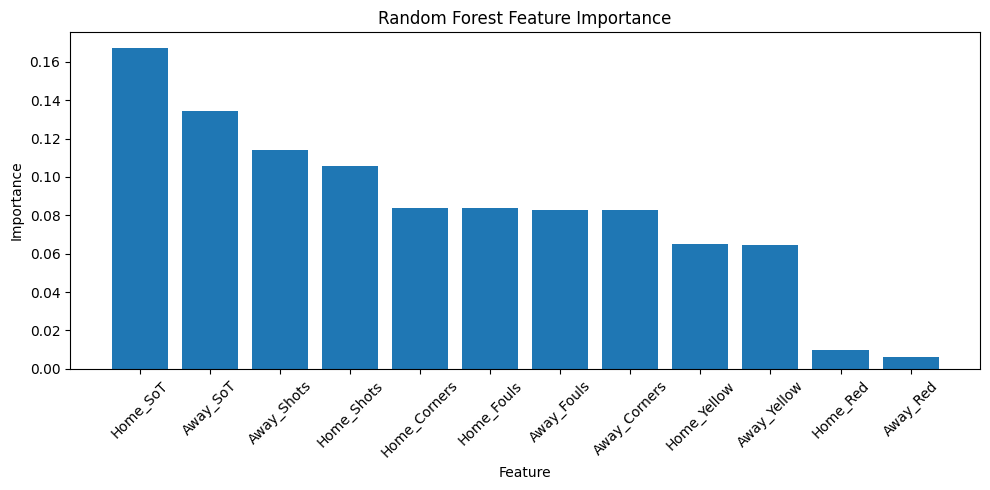

In [19]:
# Random Forest (Part C) - Feature Importance

importances = pd.Series(best_rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(importances.index, importances.values)
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Part 4 Summary:**

Softmax Regression (Best: C=0.01, solver=lbfgs, max_iter=100)
 - Train: 0.6053, Val: 0.5731, Test: 0.6784
 - Higher regularization (C=0.01) worked best, increasing C hurt performance
   suggesting overfitting with less regularization.

SVM (Best: C=1.0, kernel=rbf, gamma=auto)
 - Train: 0.6867, Val: 0.5906, Test: 0.6608
 - RBF kernel outperformed linear and poly. Poly kernel performed worst overall. SVM outperformed softmax on validation accuracy.

Random Forest (Best: n_estimators=100, max_depth=None, min_samples_split=5, min_samples_leaf=2)
 - Train: 0.9662, Val: 0.6140, Test: 0.6082
 - The large gap between train and val indicates significant
   overfitting despite unlimited depth producing the best val accuracy. Random
   Forest achieved the highest val accuracy of all three models.
 - The feature importance for Random Forest aligns with the Result vs. feature correlation heatmap

Overall, Random Forest had the best validation accuracy but also the
most overfitting.

# **PART 5:**


In [17]:
# Ensemble
# Also ran code using soft voting, but changed code back to hard as it was the better model

from sklearn.ensemble import VotingClassifier

# Hard voting not used, soft performed better
ensemble = VotingClassifier(estimators=[('softmax', best_model), ('svm', best_svm), ('rf', best_rf)], voting='hard')
ensemble.fit(X_train_scaled, y_train)

ensemble_soft = VotingClassifier(estimators=[('softmax', best_model), ('svm', SVC(C=1.0, kernel='rbf', gamma='auto', probability=True)), ('rf', best_rf)], voting='soft')
ensemble_soft.fit(X_train_scaled, y_train)

train_pred = ensemble_soft.predict(X_train_scaled)
val_pred = ensemble_soft.predict(X_val_scaled)
test_pred = ensemble_soft.predict(X_test_scaled)

print("Train Accuracy: ", round(accuracy_score(y_train, train_pred), 4))
print("Train Precision: ", round(precision_score(y_train, train_pred, average='macro'), 4))
print("Train Recall: ", round(recall_score(y_train, train_pred, average='macro'), 4))
print("Train F1: ", round(f1_score(y_train, train_pred, average='macro'), 4))

print("\nVal Accuracy: ", round(accuracy_score(y_val, val_pred), 4))
print("Val Precision: ", round(precision_score(y_val, val_pred, average='macro'), 4))
print("Val Recall: ", round(recall_score(y_val, val_pred, average='macro'), 4))
print("Val F1: ", round(f1_score(y_val, val_pred, average='macro'), 4))

print("\nTest Accuracy: ", round(accuracy_score(y_test, test_pred), 4))
print("Test Precision: ", round(precision_score(y_test, test_pred, average='macro'), 4))
print("Test Recall: ", round(recall_score(y_test, test_pred, average='macro'), 4))
print("Test F1: ", round(f1_score(y_test, test_pred, average='macro'), 4))

Train Accuracy:  0.7544
Train Precision:  0.8246
Train Recall:  0.6908
Train F1:  0.6915

Val Accuracy:  0.6082
Val Precision:  0.6264
Val Recall:  0.5453
Val F1:  0.5083

Test Accuracy:  0.6784
Test Precision:  0.5863
Test Recall:  0.5668
Test F1:  0.5298


**Part 5 Summary:**

Used two ensemble approaches, soft and hard, both combined softmax regression, SVM, and random forest models.

Hard voting:
 - Val: 0.5906, Test: 0.6725

Soft voting:
 - Val: 0.6023, Test: 0.6784

The soft voting ensemble outperformed Softmax (0.5731) and SVM
(0.5906) on validation sets but performed worse than SVM (0.614). The hard voting ensemble showed similar results. Neither ensemble was able to perform better than the best individual classifier, Random Forest.

This suggests that since Random Forest is already the strongest model, adding the weaker Softmax and SVM predictions into the vote reduces the overall accuracy rather than improving it.